In [1]:
import pandas as pd
import pyarrow as pa
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# January Data
df_jan = pd.read_parquet('yellow_tripdata_2023-01.parquet')
df_jan.head().T
#len(df_jan.columns)

# February Data
#df_feb = pd.read_parquet('yellow_tripdata_2023-02.parquet')
#df_feb.head().T
#len(df_feb.columns)

,0,1,2,3,4
VendorID,2,2,2,1,2
tpep_pickup_datetime,2023-01-01 00:32:10,2023-01-01 00:55:08,2023-01-01 00:25:04,2023-01-01 00:03:48,2023-01-01 00:10:29
tpep_dropoff_datetime,2023-01-01 00:40:36,2023-01-01 01:01:27,2023-01-01 00:37:49,2023-01-01 00:13:25,2023-01-01 00:21:19
passenger_count,1.0,1.0,1.0,0.0,1.0
trip_distance,0.97,1.1,2.51,1.9,1.43
RatecodeID,1.0,1.0,1.0,1.0,1.0
store_and_fwd_flag,N,N,N,N,N
PULocationID,161,43,48,138,107
DOLocationID,141,237,238,7,79
payment_type,2,1,1,1,1


In [1]:
# Add a duration column
df_jan['duration'] = df_jan.tpep_dropoff_datetime - df_jan.tpep_pickup_datetime
df_jan.duration = df_jan.duration.apply(lambda td: td.total_seconds()/60 )

df_jan.head().T

NameError: name 'df_jan' is not defined

In [4]:
# Mean
df_jan.duration.mean()

np.float64(15.668995167330449)

In [5]:
# Standard Deviation
df_jan.duration.std()

42.594351241920904

In [6]:
# describe the data
df_jan.duration.describe()

count    3.066766e+06
mean     1.566900e+01
std      4.259435e+01
min     -2.920000e+01
25%      7.116667e+00
50%      1.151667e+01
75%      1.830000e+01
max      1.002918e+04
Name: duration, dtype: float64

In [7]:
# Full decimal
df_jan.duration.describe().apply(lambda x: format(x, 'f'))

count    3066766.000000
mean          15.668995
std           42.594351
min          -29.200000
25%            7.116667
50%           11.516667
75%           18.300000
max        10029.183333
Name: duration, dtype: object

In [8]:
# Trim
df_jan = df_jan[(df_jan.duration >= 1) & (df_jan.duration <= 60)].copy()

In [9]:
# Check after trim
df_jan.duration.describe().apply(lambda x: format(x, 'f'))

count    3009173.000000
mean          14.204864
std            9.939386
min            1.000000
25%            7.216667
50%           11.550000
75%           18.183333
max           60.000000
Name: duration, dtype: object

In [10]:
# Percentage after trim
len(df_jan[(df_jan.duration >= 1) & (df_jan.duration <=60 )]) / len(df_jan) * 100

100.0

In [11]:
# Unique PULocationID
len(df_jan.PULocationID.unique())

255

In [12]:
# one hot encoding
categorical = ['PULocationID','DOLocationID']

df_jan[categorical] = df_jan[categorical].astype(str)

In [13]:
train_dicts = df_jan[categorical].to_dict(orient="records")

In [14]:
dv = DictVectorizer()

In [15]:
print(train_dicts[:2])

[{'PULocationID': '161', 'DOLocationID': '141'}, {'PULocationID': '43', 'DOLocationID': '237'}]


In [16]:
X_train = dv.fit_transform(train_dicts)

In [17]:
print(f'Feature matrix size: {X_train.shape}')

Feature matrix size: (3009173, 515)


In [18]:
#target = 'duration'
y_train = df_jan['duration'].values

In [19]:
lr = LinearRegression()

In [20]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = lr.predict(X_train)

In [22]:
print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred))}')

Train RMSE: 7.649261932456945


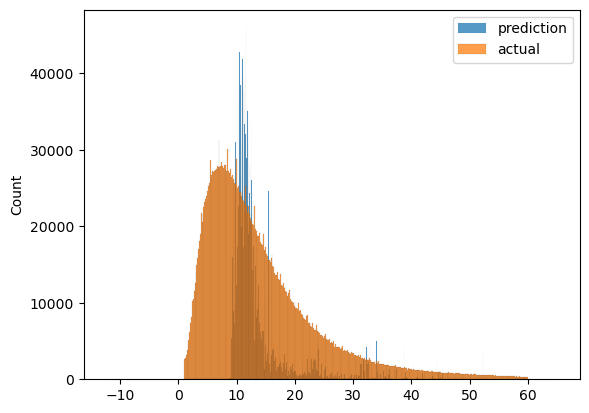

In [23]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend();

In [39]:
categorical = ['PULocationID', 'DOLocationID']

def read_data(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)].copy()

    df[categorical] = df[categorical].astype('str')
    
    return df

In [33]:
df_feb = read_data('yellow_tripdata_2023-02.parquet')

In [35]:
val_dicts = df_feb[categorical].to_dict(orient='records')

In [36]:
X_val = dv.transform(val_dicts)

In [38]:
y_val = df_feb.duration.values

In [40]:
y_pred = lr.predict(X_val)

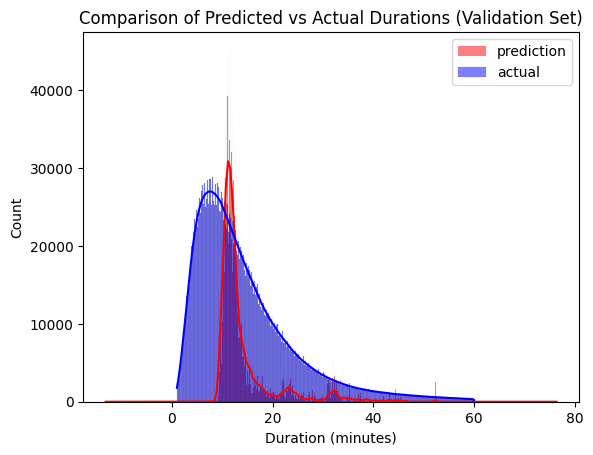

In [42]:
sns.histplot(y_pred, label='prediction', color='red', kde=True)
sns.histplot(y_val, label='actual', color='blue', kde=True)

plt.title('Comparison of Predicted vs Actual Durations (Validation Set)')
plt.xlabel('Duration (minutes)')
plt.legend()
plt.show()